In [1]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("airbnb_london.csv")

# Remove extreme prices
df_cap = df[df['price'] < 1000]

print(df_cap.head())

            neighbourhood        room_type   price  minimum_nights  \
0             Hammersmith  Entire home/apt  148.55               6   
1  Kensington and Chelsea     Private room  393.56              29   
2                  Camden  Entire home/apt  197.64              19   
3               Southwark     Private room   70.47               6   
4             Hammersmith     Private room   96.58              18   

   number_of_reviews  availability_365  reviews_per_month  
0                158               302               3.75  
1                 46               323               2.56  
2                242               291               2.52  
3                199                22               1.24  
4                110               103               4.11  


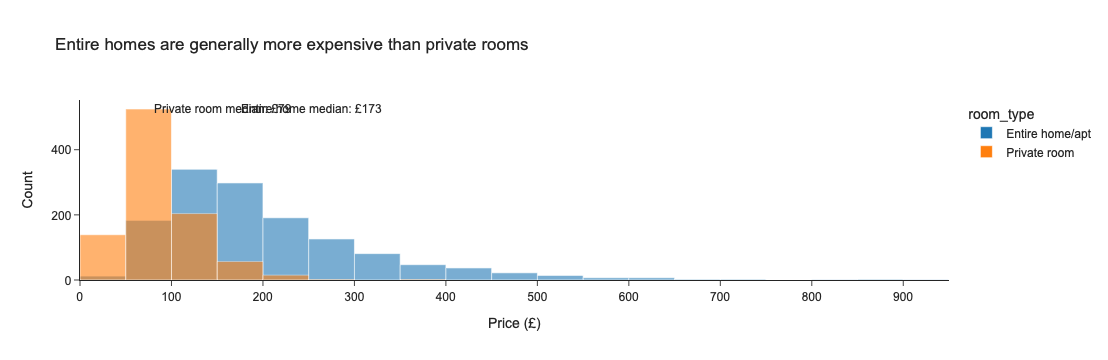

In [2]:
# Task 1

room_df = df_cap[
    df_cap['room_type'].isin([
        'Entire home/apt',
        'Private room'
    ])
]

fig = px.histogram(
    room_df,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    title='Entire homes are generally more expensive than private rooms',
    template='simple_white'
)

median_entire = room_df[
    room_df['room_type'] == 'Entire home/apt'
]['price'].median()

median_private = room_df[
    room_df['room_type'] == 'Private room'
]['price'].median()

fig.add_vline(
    x=median_entire,
    line_color='blue',
    annotation_text=f'Entire home median: £{median_entire:.0f}'
)

fig.add_vline(
    x=median_private,
    line_color='red',
    annotation_text=f'Private room median: £{median_private:.0f}'
)

fig.update_layout(
    font=dict(family='Arial'),
    xaxis_title='Price (£)',
    yaxis_title='Count'
)

fig.show()

In [ ]:
#Insight
#Entire homes/apartments are typically more expensive than private rooms, with a much wider price distribution across listings.

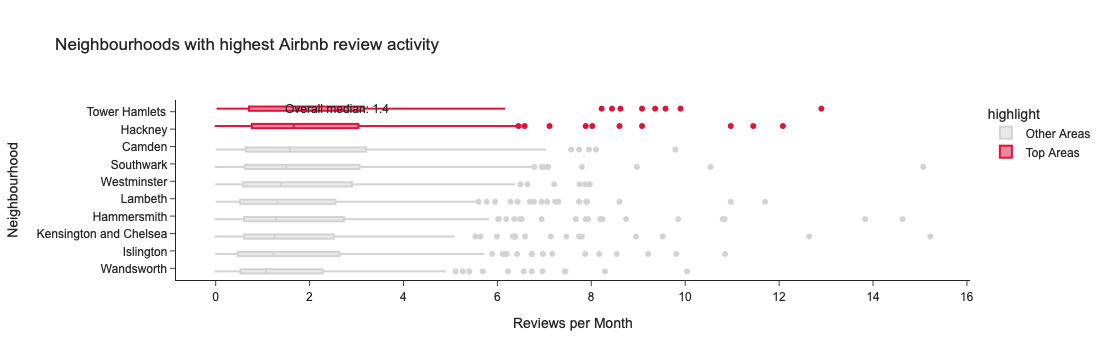

In [5]:
# Task 2

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("airbnb_london.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Remove missing values
activity_df = df.dropna(subset=['reviews_per_month']).copy()

# Find top neighbourhoods by median reviews
borough_order = (
    activity_df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

# Top 2 neighbourhoods
top_two = borough_order.head(2).index.tolist()

# Highlight top neighbourhoods
activity_df['highlight'] = activity_df['neighbourhood'].apply(
    lambda x: 'Top Areas' if x in top_two else 'Other Areas'
)

# Create box plot
fig = px.box(
    activity_df,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    category_orders={
        'neighbourhood': borough_order.index.tolist()
    },
    color_discrete_map={
        'Top Areas': 'crimson',
        'Other Areas': '#D3D3D3'
    },
    title='Neighbourhoods with highest Airbnb review activity',
    template='simple_white'
)

# Add overall median line
overall_median = activity_df['reviews_per_month'].median()

fig.add_vline(
    x=overall_median,
    line_dash='dash',
    annotation_text=f'Overall median: {overall_median:.1f}'
)

# Layout
fig.update_layout(
    font=dict(family='Arial'),
    xaxis_title='Reviews per Month',
    yaxis_title='Neighbourhood'
)

fig.show()

In [ ]:
#Insight
#Certain London neighbourhoods receive significantly more reviews per month, indicating higher Airbnb activity and stronger guest demand in those areas.